# Lab 2: End-to-End Cancer Diagnosis Support with Classification and Clustering

<!--
This lab reviews weeks 2-5 through a second realistic end-to-end system.
Lab 1 focused on housing regression and clustering.
Lab 2 focuses on cancer classification and clustering.

The matching Theory 2 file will be written after review. This file is the practical lab.
-->

- [1. From a Business Question to Machine Learning Tasks](#1-from-a-business-question-to-machine-learning-tasks)
  - [1.1 Understand the business objective](#11-understand-the-business-objective)
  - [1.2 Separate the classification and clustering questions](#12-separate-the-classification-and-clustering-questions)
- [2. Load and Understand the Cancer Dataset](#2-load-and-understand-the-cancer-dataset)
  - [2.1 Import libraries](#21-import-libraries)
  - [2.2 Load the data](#22-load-the-data)
  - [2.3 Inspect rows, columns, and data types](#23-inspect-rows-columns-and-data-types)
  - [2.4 Identify features, target, and classes](#24-identify-features-target-and-classes)
- [3. Initial EDA and Data Quality](#3-initial-eda-and-data-quality)
  - [3.1 Check missing values and duplicates](#31-check-missing-values-and-duplicates)
  - [3.2 Explore the target distribution](#32-explore-the-target-distribution)
  - [3.3 Explore feature distributions](#33-explore-feature-distributions)
  - [3.4 Compare features by diagnosis](#34-compare-features-by-diagnosis)
  - [3.5 Inspect correlations](#35-inspect-correlations)
- [4. Classification System: Predict Diagnosis](#4-classification-system-predict-diagnosis)
  - [4.1 Select features and target](#41-select-features-and-target)
  - [4.2 Split before learned preprocessing](#42-split-before-learned-preprocessing)
  - [4.3 Build a baseline](#43-build-a-baseline)
  - [4.4 Standardize features for distance-based and coefficient-based models](#44-standardize-features-for-distance-based-and-coefficient-based-models)
  - [4.5 Train logistic regression](#45-train-logistic-regression)
  - [4.6 Train K-nearest neighbors](#46-train-k-nearest-neighbors)
  - [4.7 Train a decision tree](#47-train-a-decision-tree)
  - [4.8 Compare classification metrics](#48-compare-classification-metrics)
  - [4.9 Inspect the confusion matrix](#49-inspect-the-confusion-matrix)
  - [4.10 Interpret prediction probabilities](#410-interpret-prediction-probabilities)
- [5. Clustering System: Discover Tumor Measurement Profiles](#5-clustering-system-discover-tumor-measurement-profiles)
  - [5.1 Change the question](#51-change-the-question)
  - [5.2 Select clustering features](#52-select-clustering-features)
  - [5.3 Standardize clustering features](#53-standardize-clustering-features)
  - [5.4 Compare candidate K values](#54-compare-candidate-k-values)
  - [5.5 Profile the selected K-Means clusters](#55-profile-the-selected-k-means-clusters)
  - [5.6 Compare clusters with diagnosis after fitting](#56-compare-clusters-with-diagnosis-after-fitting)
  - [5.7 Compare with agglomerative clustering](#57-compare-with-agglomerative-clustering)
- [6. Connect the Lab to Real Project Practice](#6-connect-the-lab-to-real-project-practice)
- [7. Final Concept Review and Exam-Style Questions](#7-final-concept-review-and-exam-style-questions)

## Learning Objectives

By the end of this lab, you should be able to:

- translate a business objective into classification and clustering questions;
- distinguish classification from regression;
- distinguish binary classification from multiclass classification;
- identify features, target, and class labels;
- perform focused EDA before modeling;
- check missing values, duplicates, class balance, distributions, and correlations;
- create a train/test split for supervised classification;
- explain and avoid data leakage;
- build a baseline classifier;
- standardize numerical features when appropriate;
- train logistic regression, K-nearest neighbors, and a decision tree;
- evaluate classification using accuracy, precision, recall, F1, and a confusion matrix;
- explain false positives and false negatives in a medical-support context;
- use K-Means and agglomerative clustering to explore tumor measurement profiles;
- explain what this system can and cannot prove.

## 1. From a Business Question to Machine Learning Tasks

### 1.1 Understand the business objective

Imagine you have joined a health analytics team. The team studies measurements taken from breast mass images. Each row describes one case using numerical measurements such as radius, texture, smoothness, compactness, concavity, and symmetry.

The business team asks:

> Can we use tumor measurements to support diagnosis review and discover groups of similar cases?

This is not yet a machine-learning task. In practice, we must clarify what the model is for.

Possible uses include:

- supporting a clinical review workflow;
- flagging cases that need careful human attention;
- comparing simple classification models;
- exploring whether cases form measurement-based profiles.

This lab is for learning machine learning. It is not a medical device, and it must not be treated as medical advice.

**Question 1 — Business objective versus model objective**

Why is the business objective not the same thing as the model objective?

<details>
<summary>Solution</summary>

The business objective describes the real-world purpose: supporting diagnosis review and understanding similar cases.

The model objective is more specific. For classification, the model predicts a class label from input features. For clustering, the model groups observations using feature similarity.

A useful real-world system needs both: a clear practical purpose and a clear modeling task.

</details>

### 1.2 Separate the classification and clustering questions

This lab builds two connected systems from the same dataset.

**System A: Classification**

```text
Tumor measurements → predict diagnosis class
```

This is supervised learning because the training data contains known diagnosis labels.

**System B: Clustering**

```text
Tumor measurements → discover similar measurement profiles
```

This is unsupervised learning because the clustering algorithm does not use the diagnosis label during fitting.

**Question 2 — Classification or clustering?**

A model predicts whether a case is malignant or benign. Is this classification or clustering?

<details>
<summary>Solution</summary>

This is classification because the model predicts a known category label.

The target contains two possible classes, so it is binary classification.

</details>

**Question 3 — Classification or clustering?**

A model groups cases using only measurement similarity and does not use the diagnosis label while fitting. Is this classification or clustering?

<details>
<summary>Solution</summary>

This is clustering because the model discovers groups without using a known target label during fitting.

</details>

## 2. Load and Understand the Cancer Dataset

### 2.1 Import libraries

Run this setup cell first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

**Code explanation**

- `load_breast_cancer` loads the dataset directly from scikit-learn.
- `train_test_split` separates data used for learning from data used for evaluation.
- `StandardScaler` standardizes features for models affected by scale.
- `DummyClassifier` creates a simple baseline.
- `LogisticRegression`, `KNeighborsClassifier`, and `DecisionTreeClassifier` are classification models.
- Accuracy, precision, recall, F1, confusion matrix, and classification report evaluate classification.
- `KMeans` and `AgglomerativeClustering` create clusters.
- `silhouette_score` helps compare clustering results.

### 2.2 Load the data

This dataset is built into scikit-learn, so students can run it directly in Google Colab.

In [2]:
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["diagnosis"] = cancer.target
df["diagnosis_name"] = df["diagnosis"].map({
    0: cancer.target_names[0],
    1: cancer.target_names[1],
})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
print("Target names:", cancer.target_names)
print("Feature count:", len(cancer.feature_names))
print("Rows and columns:", df.shape)

Target names: ['malignant' 'benign']
Feature count: 30
Rows and columns: (569, 32)


**Code explanation**

- `cancer.data` contains the numerical input features.
- `cancer.target` contains the known diagnosis class.
- `diagnosis_name` gives readable class labels.
- In this dataset, scikit-learn uses `0 = malignant` and `1 = benign`.

### 2.3 Inspect rows, columns, and data types

Before modeling, inspect the structure.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


**Code explanation**

- `info()` shows columns, non-missing counts, and data types.
- `describe()` summarizes numerical columns.
- `head()` shows example rows.

**Question 4 — Row meaning**

What does one row represent in this dataset?

<details>
<summary>Solution</summary>

One row represents one breast mass case described by numerical measurements and a known diagnosis label.

</details>

### 2.4 Identify features, target, and classes

In this dataset:

- the input features are numerical measurements;
- the target is `diagnosis`;
- the readable target is `diagnosis_name`;
- this is binary classification because there are two classes.

In [7]:
target = "diagnosis"
readable_target = "diagnosis_name"
feature_columns = cancer.feature_names.tolist()

print("Number of features:", len(feature_columns))
print("Target:", target)
print("Classes:")
print(df[[target, readable_target]].drop_duplicates().sort_values(target))

Number of features: 30
Target: diagnosis
Classes:
    diagnosis diagnosis_name
0           0      malignant
19          1         benign


**Question 5 — Features and target**

Why should `diagnosis` and `diagnosis_name` not be included as input features?

<details>
<summary>Solution</summary>

They contain the answer we want the model to predict.

Including the target as an input feature would cause data leakage. The model would appear to perform extremely well because it was given the answer.

</details>

## 3. Initial EDA and Data Quality

### 3.1 Check missing values and duplicates

In [8]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(10)

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


**Code explanation**

- Missing values may require imputation.
- Duplicates may distort model evaluation if repeated cases appear in both training and test sets.
- This dataset is already clean, but we still check.

**Question 6 — Data quality**

If this dataset has no missing values, why do we still check for them?

<details>
<summary>Solution</summary>

Checking data quality is part of the workflow.

In real projects, datasets often change. A clean dataset today does not guarantee that future data will always be clean.

</details>

### 3.2 Explore the target distribution

In [10]:
class_counts = df[readable_target].value_counts()
class_counts

,count
diagnosis_name,
benign,357
malignant,212


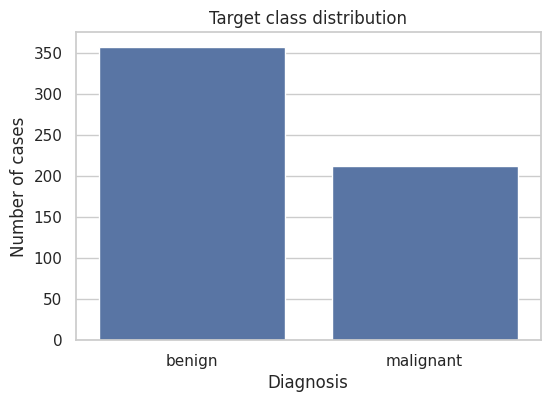

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=readable_target, order=class_counts.index)
plt.xlabel("Diagnosis")
plt.ylabel("Number of cases")
plt.title("Target class distribution")
plt.show()

In [12]:
class_percentages = df[readable_target].value_counts(normalize=True).mul(100).round(1)
class_percentages

,proportion
diagnosis_name,
benign,62.7
malignant,37.3


**Code explanation**

- `value_counts()` shows how many observations are in each class.
- Class balance matters because accuracy can be misleading when one class is much more common.
- The most frequent class also gives a useful baseline.

**Question 7 — Baseline thinking**

If most cases are benign, why might a classifier with high accuracy still be weak?

<details>
<summary>Solution</summary>

A classifier can get many cases correct by mostly predicting the majority class.

In medical-support problems, we also care about the types of mistakes. Missing malignant cases can be much more serious than the overall accuracy suggests.

</details>

### 3.3 Explore feature distributions

Start with a few representative features.

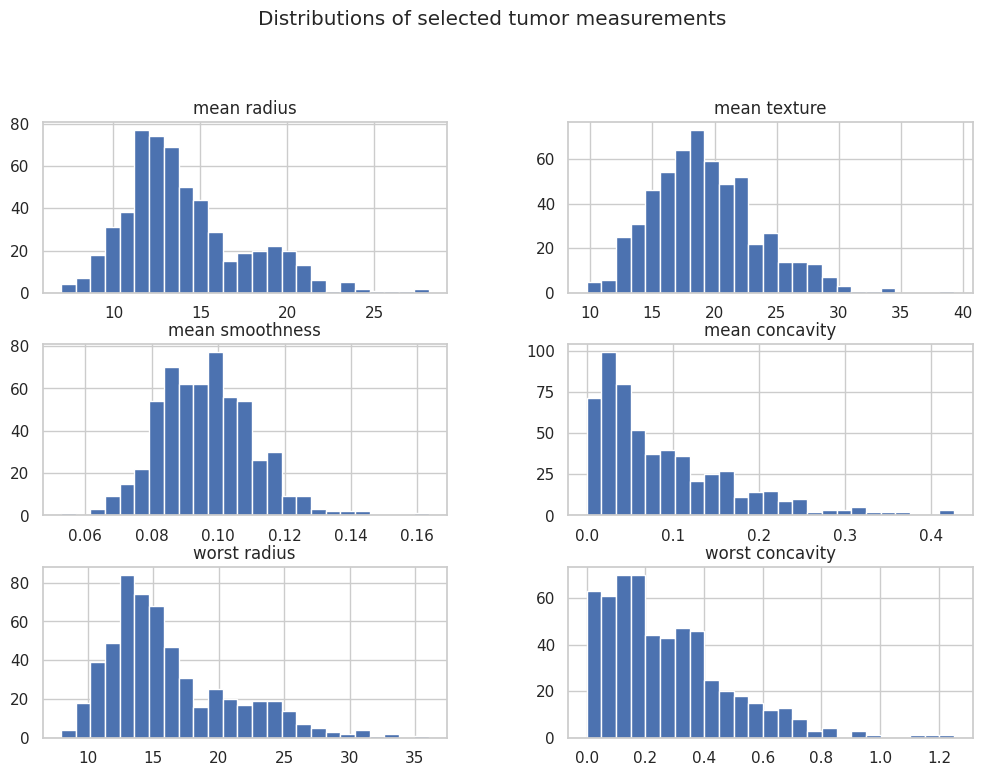

In [13]:
selected_eda_features = [
    "mean radius",
    "mean texture",
    "mean smoothness",
    "mean concavity",
    "worst radius",
    "worst concavity",
]

df[selected_eda_features].hist(figsize=(12, 8), bins=25)
plt.suptitle("Distributions of selected tumor measurements", y=1.02)
plt.show()

**Code explanation**

- Histograms show the shape and range of each feature.
- Some features have larger numerical ranges than others.
- Large differences in scale matter for distance-based models such as KNN and K-Means.

### 3.4 Compare features by diagnosis

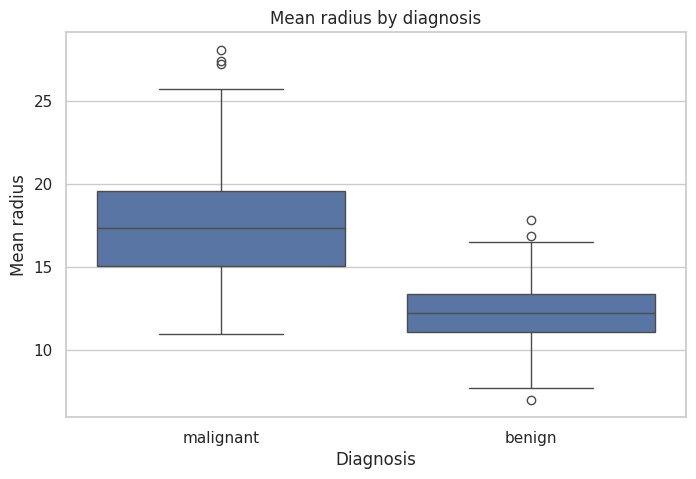

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=readable_target, y="mean radius")
plt.xlabel("Diagnosis")
plt.ylabel("Mean radius")
plt.title("Mean radius by diagnosis")
plt.show()

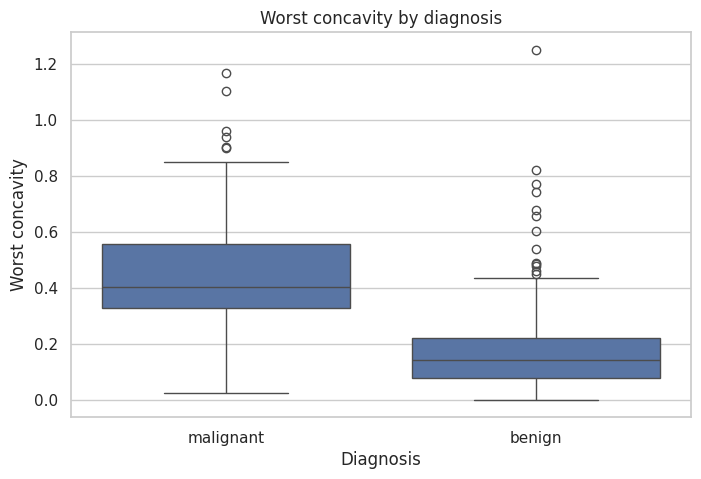

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=readable_target, y="worst concavity")
plt.xlabel("Diagnosis")
plt.ylabel("Worst concavity")
plt.title("Worst concavity by diagnosis")
plt.show()

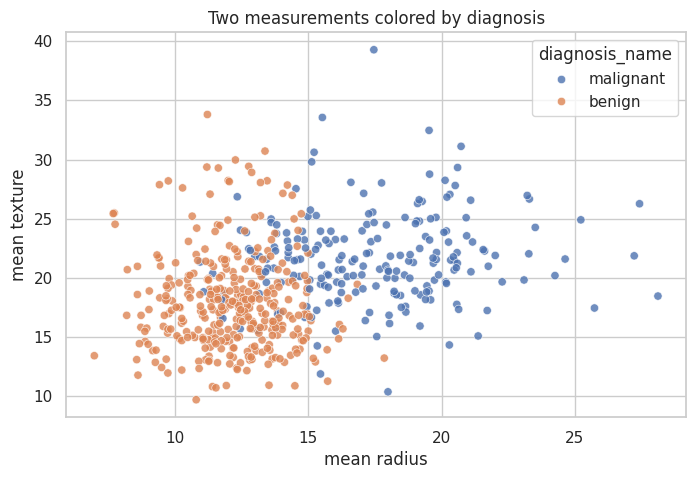

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue=readable_target,
    alpha=0.8,
)
plt.title("Two measurements colored by diagnosis")
plt.show()

**Code explanation**

- Boxplots compare distributions between classes.
- Scatterplots help us see whether classes are separated in two selected features.
- We do not expect two features to explain everything.

**Question 8 — EDA and modeling**

Why is it useful to compare feature distributions by diagnosis before training a classifier?

<details>
<summary>Solution</summary>

It helps us understand whether some features may contain useful class information.

It also helps us notice overlap. If the classes overlap strongly, the task may be difficult and mistakes should be expected.

</details>

### 3.5 Inspect correlations

Correlation is not the main evaluation tool for classification, but it still helps us understand numerical relationships.

In [17]:
correlation_with_target = (
    df[feature_columns + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

correlation_with_target.head(10)

,diagnosis
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


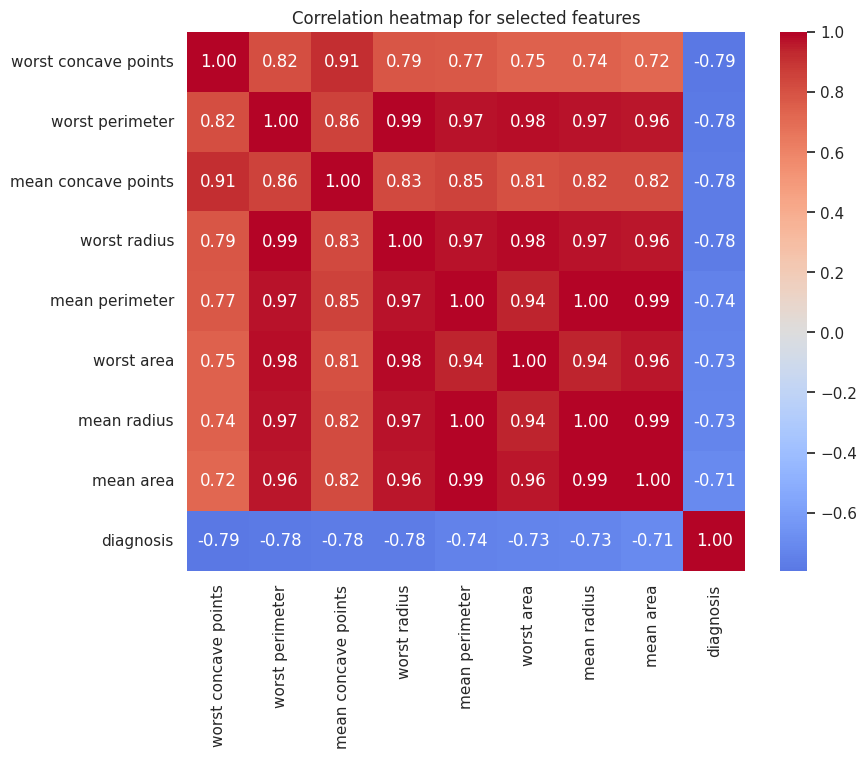

In [18]:
top_corr_features = correlation_with_target.head(8).index.tolist()

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[top_corr_features + [target]].corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
)
plt.title("Correlation heatmap for selected features")
plt.show()

**Code explanation**

- `corr()` calculates Pearson correlation between numerical columns.
- Because `diagnosis` is coded as `0` and `1`, correlation with the target gives an initial view of linear association with the class code.
- This does not replace classifier evaluation.

**Question 9 — Correlation limitation**

Why should we not choose the classifier only from Pearson correlations?

<details>
<summary>Solution</summary>

Pearson correlation measures linear association between two numerical columns.

Classification models may use several features together, and some relationships may not be captured by a single correlation value.

Correlation is useful for investigation, but it is not the final model-selection method.

</details>

## 4. Classification System: Predict Diagnosis

### 4.1 Select features and target

In [19]:
X = df[feature_columns]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


**Code explanation**

- `X` contains the input measurements.
- `y` contains the diagnosis class.
- The readable diagnosis label is not included in `X`.

### 4.2 Split before learned preprocessing

Split the data before fitting scalers or models.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training class counts:")
print(y_train.value_counts().sort_index())
print("Test class counts:")
print(y_test.value_counts().sort_index())

Training rows: 455
Test rows: 114
Training class counts:
diagnosis
0    170
1    285
Name: count, dtype: int64
Test class counts:
diagnosis
0    42
1    72
Name: count, dtype: int64


**Code explanation**

- `test_size=0.2` keeps 20 percent of rows for testing.
- `random_state=42` makes the split reproducible.
- `stratify=y` keeps class proportions similar in train and test sets.

**Question 10 — Stratification**

Why is `stratify=y` useful in classification?

<details>
<summary>Solution</summary>

It helps keep the class distribution similar in the training and test sets.

This is useful because evaluation can be misleading if the test set has very different class proportions from the data used for training.

</details>

### 4.3 Build a baseline

A baseline is a simple reference model.

Here the baseline always predicts the most frequent training class.

In [21]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [22]:
def classification_scores(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
    }

results = []
results.append(
    classification_scores("Most frequent baseline", y_test, baseline_predictions)
)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,Most frequent baseline,0.631579,0.0,0.0,0.0


**Code explanation**

- `DummyClassifier` creates a simple baseline.
- `strategy="most_frequent"` always predicts the majority class from the training data.
- We use `pos_label=0` so precision, recall, and F1 focus on the malignant class.

**Question 11 — Positive class**

Why might we focus precision and recall on the malignant class?

<details>
<summary>Solution</summary>

In this dataset, `0` means malignant.

For a diagnosis-support task, missing malignant cases is especially important. Focusing metrics on the malignant class helps us inspect how well the model identifies that class.

</details>

### 4.4 Standardize features for distance-based and coefficient-based models

KNN uses distances, so feature scale matters. Logistic regression can also behave better when numerical features are on comparable scales.

Fit the scaler on the training data only.

In [23]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns,
    index=X_test.index,
)

X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


**Code explanation**

- `fit_transform()` learns means and standard deviations from training data, then applies them to training data.
- `transform()` applies the same learned scaling to test data.
- We do not fit a new scaler on the test set.

**Question 12 — Leakage**

Why should the scaler be fitted on the training data only?

<details>
<summary>Solution</summary>

The test set should represent unseen data.

If we use the test set to learn scaling values, information from the test set influences preprocessing. That is data leakage.

</details>

### 4.5 Train logistic regression

Logistic regression is a classification algorithm. It estimates class membership using learned coefficients.

In [24]:
logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_predictions[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

In [25]:
results.append(
    classification_scores("Logistic regression", y_test, logistic_predictions)
)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,Most frequent baseline,0.631579,0.00000,0.00000,0.00000
1,Logistic regression,0.982456,0.97619,0.97619,0.97619


**Code explanation**

- `fit()` learns from the scaled training features and training target.
- `predict()` returns class labels for the test data.
- Logistic regression is used here as a classifier, not as a regression model.

**Question 13 — Logistic regression**

Why is logistic regression used for classification even though its name contains "regression"?

<details>
<summary>Solution</summary>

Logistic regression models the probability of belonging to a class, then converts that probability into a class prediction.

In this course context, it is a classification algorithm.

</details>

### 4.6 Train K-nearest neighbors

KNN classifies a new observation by looking at nearby training observations.

In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)
knn_predictions[:10]

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

In [27]:
results.append(
    classification_scores("KNN, k=5", y_test, knn_predictions)
)

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,Most frequent baseline,0.631579,0.00000,0.000000,0.000000
1,Logistic regression,0.982456,0.97619,0.976190,0.976190
2,"KNN, k=5",0.956140,0.95122,0.928571,0.939759


**Code explanation**

- `n_neighbors=5` means the classifier uses the five nearest training observations.
- KNN depends on distances, so scaling matters.
- The model needs the training observations when making predictions because it compares new cases to stored cases.

**Question 14 — KNN and scaling**

Why can KNN perform poorly when features are not scaled?

<details>
<summary>Solution</summary>

KNN uses distances.

If one feature has much larger numerical values than another, it can dominate the distance calculation even if it is not more important.

</details>

### 4.7 Train a decision tree

A decision tree learns a sequence of feature-based questions.

In [28]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_predictions[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

In [29]:
results.append(
    classification_scores("Decision tree, depth 4", y_test, tree_predictions)
)

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Most frequent baseline,0.631579,0.000000,0.000000,0.000000
1,Logistic regression,0.982456,0.976190,0.976190,0.976190
2,"KNN, k=5",0.956140,0.951220,0.928571,0.939759
3,"Decision tree, depth 4",0.938596,0.906977,0.928571,0.917647


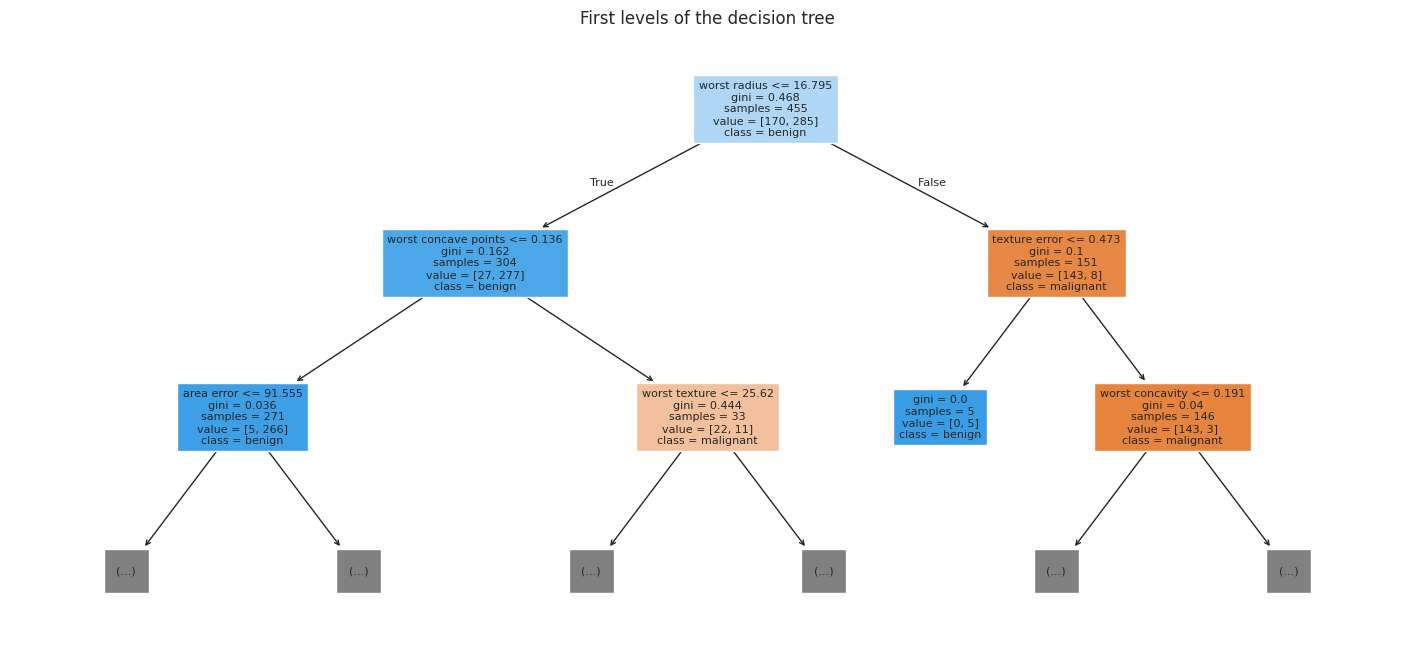

In [30]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=feature_columns,
    class_names=cancer.target_names,
    filled=True,
    max_depth=2,
    fontsize=8,
)
plt.title("First levels of the decision tree")
plt.show()

**Code explanation**

- A decision tree repeatedly splits the data using feature rules.
- `max_depth=4` limits tree complexity.
- The tree is trained on unscaled features because decision trees do not depend on distance calculations in the same way as KNN.

**Question 15 — Decision tree**

How does a decision tree make a classification?

<details>
<summary>Solution</summary>

It follows a sequence of feature-based decisions.

For example, it may ask whether a measurement is below or above a threshold. After several splits, the case reaches a leaf node with a predicted class.

</details>

### 4.8 Compare classification metrics

In [31]:
results_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
1,Logistic regression,0.982456,0.976190,0.976190,0.976190
2,"KNN, k=5",0.956140,0.951220,0.928571,0.939759
3,"Decision tree, depth 4",0.938596,0.906977,0.928571,0.917647
0,Most frequent baseline,0.631579,0.000000,0.000000,0.000000


In [32]:
print("Logistic regression report:")
print(classification_report(
    y_test,
    logistic_predictions,
    target_names=cancer.target_names,
))

Logistic regression report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Code explanation**

- Accuracy is the proportion of correct predictions.
- Precision answers: of the cases predicted as a class, how many were actually that class?
- Recall answers: of the actual cases in a class, how many did the model find?
- F1 combines precision and recall.
- The classification report gives metrics for each class.

**Question 16 — Accuracy**

Why is accuracy alone not always enough?

<details>
<summary>Solution</summary>

Accuracy gives one overall number.

It can hide which class is being misclassified. In medical-support problems, the type of mistake matters, not only the total number of correct predictions.

</details>

**Question 17 — Precision and recall**

In this lab, what is the difference between precision for malignant cases and recall for malignant cases?

<details>
<summary>Solution</summary>

Precision for malignant cases asks:

```text
Of the cases predicted malignant, how many were actually malignant?
```

Recall for malignant cases asks:

```text
Of the truly malignant cases, how many did the model identify as malignant?
```

</details>

### 4.9 Inspect the confusion matrix

Use the logistic regression model for detailed inspection.

In [33]:
cm = confusion_matrix(y_test, logistic_predictions)
cm

array([[41,  1],
       [ 1, 71]])

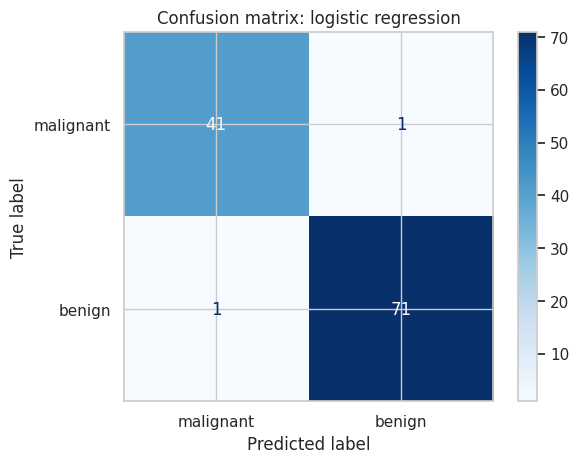

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names,
)
disp.plot(cmap="Blues")
plt.title("Confusion matrix: logistic regression")
plt.show()

In [35]:
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in cancer.target_names],
    columns=[f"Predicted {name}" for name in cancer.target_names],
)
cm_df

,Predicted malignant,Predicted benign
Actual malignant,41,1
Actual benign,1,71


**Code explanation**

- Rows represent actual classes.
- Columns represent predicted classes.
- Diagonal values are correct predictions.
- Off-diagonal values are mistakes.

**Question 18 — False negative in context**

For the malignant class, what would it mean if an actual malignant case is predicted as benign?

<details>
<summary>Solution</summary>

That is a false negative for the malignant class.

In a diagnosis-support context, this is a serious type of error because a malignant case was not flagged as malignant by the model.

</details>

### 4.10 Interpret prediction probabilities

Some classifiers can provide class probabilities.

In [36]:
probabilities = logistic_model.predict_proba(X_test_scaled)

probability_df = pd.DataFrame(
    probabilities,
    columns=[f"probability_{name}" for name in cancer.target_names],
    index=X_test.index,
)

probability_df["actual"] = y_test.map({0: "malignant", 1: "benign"})
probability_df["predicted"] = pd.Series(
    logistic_predictions,
    index=X_test.index,
).map({0: "malignant", 1: "benign"})

probability_df.head(10)

,probability_malignant,probability_benign,actual,predicted
256,1.000000,5.888242e-08,malignant,malignant
428,0.000011,9.999887e-01,benign,benign
501,0.993589,6.410825e-03,malignant,malignant
363,0.466491,5.335085e-01,benign,benign
564,1.000000,6.525001e-10,malignant,malignant
464,0.007840,9.921604e-01,benign,benign
358,0.000017,9.999828e-01,benign,benign
343,0.999999,5.635275e-07,malignant,malignant
516,0.999946,5.431637e-05,malignant,malignant
567,1.000000,8.041849e-11,malignant,malignant


**Code explanation**

- `predict()` returns class labels.
- `predict_proba()` returns estimated probabilities for each class.
- A probability is not a guarantee. It is the model's estimate under its learned patterns.

**Question 19 — Probability interpretation**

If the model gives `probability_malignant = 0.90`, does that prove the case is malignant?

<details>
<summary>Solution</summary>

No.

It means the model estimates a high probability for the malignant class based on its learned patterns. It is not proof, and medical decisions require appropriate clinical processes.

</details>

## 5. Clustering System: Discover Tumor Measurement Profiles

### 5.1 Change the question

Classification used the diagnosis label.

Clustering asks a different question:

> Without using the diagnosis label, can we group cases that have similar tumor measurements?

This may help analysts inspect measurement profiles. It does not replace diagnosis.

**Question 20 — Target in clustering**

Should `diagnosis` be used as a clustering feature?

<details>
<summary>Solution</summary>

No.

If we use `diagnosis` as a clustering feature, the clusters are partly based on the answer label. For unsupervised exploration, we should cluster using measurement features only.

</details>

### 5.2 Select clustering features

Use a small set of interpretable measurements.

In [37]:
cluster_features = [
    "mean radius",
    "mean texture",
    "mean smoothness",
    "mean concavity",
    "worst radius",
    "worst concavity",
]

cluster_df = df[cluster_features + [target, readable_target]].copy()
cluster_df.head()

,mean radius,mean texture,mean smoothness,mean concavity,worst radius,worst concavity,diagnosis,diagnosis_name
0,17.99,10.38,0.11840,0.3001,25.38,0.7119,0,malignant
1,20.57,17.77,0.08474,0.0869,24.99,0.2416,0,malignant
2,19.69,21.25,0.10960,0.1974,23.57,0.4504,0,malignant
3,11.42,20.38,0.14250,0.2414,14.91,0.6869,0,malignant
4,20.29,14.34,0.10030,0.1980,22.54,0.4000,0,malignant


**Code explanation**

- The clustering features are all numerical measurements.
- `diagnosis` is kept only for later interpretation after clustering.
- The clustering model will not use `diagnosis` during fitting.

### 5.3 Standardize clustering features

In [38]:
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(cluster_df[cluster_features])

X_cluster_scaled[:5]

array([[ 1.09706398, -2.07333501,  1.56846633,  2.65287398,  1.88668963,
         2.10952635],
       [ 1.82982061, -0.35363241, -0.82696245, -0.02384586,  1.80592744,
        -0.14674897],
       [ 1.57988811,  0.45618695,  0.94221044,  1.36347845,  1.51187025,
         0.85497394],
       [-0.76890929,  0.25373211,  3.28355348,  1.91589718, -0.28146446,
         1.98958826],
       [ 1.75029663, -1.15181643,  0.28037183,  1.37101143,  1.29857524,
         0.61317876]])

**Code explanation**

- K-Means and agglomerative clustering use distances.
- Standardization prevents large-scale features from dominating distance calculations.
- Here the full clustering dataset is being explored. If this were a future-data scoring system, the scaling process would need to be fitted on a reference dataset.

### 5.4 Compare candidate K values

In [39]:
cluster_selection_rows = []
labels_by_k = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    labels_by_k[k] = labels

    cluster_selection_rows.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette": silhouette_score(X_cluster_scaled, labels),
    })

cluster_selection = pd.DataFrame(cluster_selection_rows)
cluster_selection

,K,Inertia,Silhouette
0,2,1953.179562,0.413287
1,3,1682.300090,0.235045
2,4,1448.920318,0.221446
3,5,1284.744130,0.227502
4,6,1130.839147,0.234320


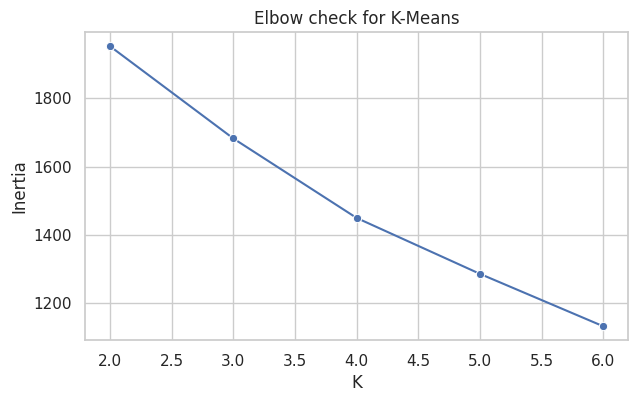

In [40]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=cluster_selection, x="K", y="Inertia", marker="o")
plt.title("Elbow check for K-Means")
plt.show()

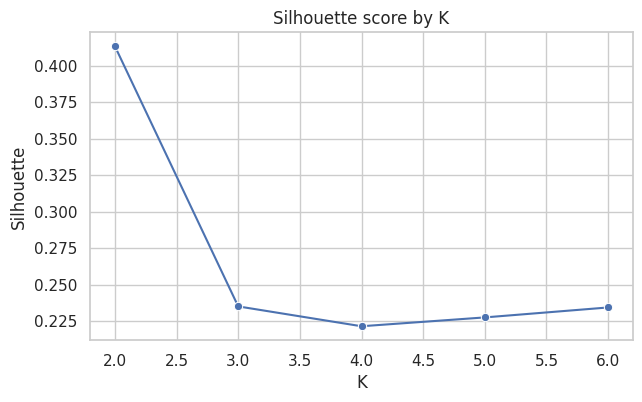

In [41]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=cluster_selection, x="K", y="Silhouette", marker="o")
plt.title("Silhouette score by K")
plt.show()

**Code explanation**

- Inertia measures compactness inside clusters.
- Inertia normally decreases as K increases, so it is not enough by itself.
- Silhouette compares separation and cohesion.
- These metrics guide interpretation; they do not prove that the clusters are clinically meaningful.

**Question 21 — K selection**

Why should we not simply choose the largest K because it has the lowest inertia?

<details>
<summary>Solution</summary>

Inertia almost always decreases when K increases because more clusters can fit the data more tightly.

Choosing K requires balancing compactness, separation, interpretability, and the purpose of the analysis.

</details>

### 5.5 Profile the selected K-Means clusters

Choose the K with the highest silhouette score for this lab.

In [42]:
best_k = int(cluster_selection.sort_values("Silhouette", ascending=False).iloc[0]["K"])
print("Selected K:", best_k)

cluster_df["cluster"] = labels_by_k[best_k]
cluster_df.head()

Selected K: 2


,mean radius,mean texture,mean smoothness,mean concavity,worst radius,worst concavity,diagnosis,diagnosis_name,cluster
0,17.99,10.38,0.11840,0.3001,25.38,0.7119,0,malignant,1
1,20.57,17.77,0.08474,0.0869,24.99,0.2416,0,malignant,1
2,19.69,21.25,0.10960,0.1974,23.57,0.4504,0,malignant,1
3,11.42,20.38,0.14250,0.2414,14.91,0.6869,0,malignant,1
4,20.29,14.34,0.10030,0.1980,22.54,0.4000,0,malignant,1


In [43]:
cluster_profile = (
    cluster_df
    .groupby("cluster")
    .agg(
        cases=("cluster", "size"),
        mean_radius=("mean radius", "mean"),
        mean_texture=("mean texture", "mean"),
        mean_smoothness=("mean smoothness", "mean"),
        mean_concavity=("mean concavity", "mean"),
        worst_radius=("worst radius", "mean"),
        worst_concavity=("worst concavity", "mean"),
    )
    .round(3)
)

cluster_profile

,cases,mean_radius,mean_texture,mean_smoothness,mean_concavity,worst_radius,worst_concavity
cluster,,,,,,,
0,393,12.410,18.205,0.093,0.047,13.777,0.172
1,176,17.962,21.712,0.105,0.183,21.833,0.496


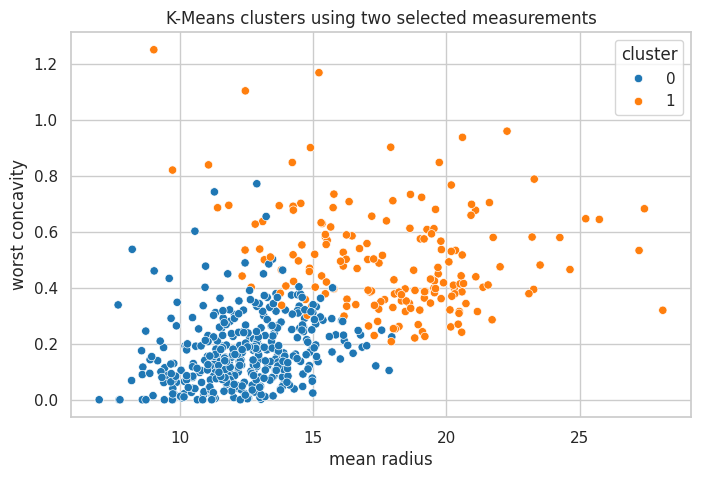

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cluster_df,
    x="mean radius",
    y="worst concavity",
    hue="cluster",
    palette="tab10",
)
plt.title("K-Means clusters using two selected measurements")
plt.show()

**Code explanation**

- Cluster numbers are labels created by the algorithm.
- Cluster `0` is not automatically better or worse than cluster `1`.
- A profile table helps us describe how clusters differ.

**Question 22 — Cluster labels**

Does cluster `0` mean "benign" and cluster `1` mean "malignant"?

<details>
<summary>Solution</summary>

No.

Cluster labels are arbitrary group names. We can compare clusters with diagnosis after fitting, but the clustering algorithm did not know the diagnosis labels.

</details>

### 5.6 Compare clusters with diagnosis after fitting

After clustering, we can compare cluster membership with diagnosis to interpret the groups.

In [45]:
cluster_diagnosis_table = pd.crosstab(
    cluster_df["cluster"],
    cluster_df[readable_target],
    normalize="index",
).round(3)

cluster_diagnosis_table

diagnosis_name,benign,malignant
cluster,,
0,0.901,0.099
1,0.017,0.983


In [46]:
pd.crosstab(cluster_df["cluster"], cluster_df[readable_target])

diagnosis_name,benign,malignant
cluster,,
0,354,39
1,3,173


**Code explanation**

- The crosstab compares clusters with known diagnosis labels after clustering.
- This is interpretation, not supervised training.
- If one cluster has many malignant cases, we can describe that pattern, but we should not claim the cluster is a diagnosis rule.

**Question 23 — Interpretation limit**

Why is it useful but risky to compare clusters with diagnosis labels?

<details>
<summary>Solution</summary>

It is useful because it helps us understand whether measurement-based clusters relate to known diagnosis.

It is risky because clusters are not supervised predictions. A cluster can contain a mix of diagnoses, and cluster labels should not be treated as medical decisions.

</details>

### 5.7 Compare with agglomerative clustering

Agglomerative clustering starts with individual observations and merges them into larger groups.

In [47]:
agg_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
cluster_df["agg_cluster"] = agg_model.fit_predict(X_cluster_scaled)

cluster_df["agg_cluster"].value_counts().sort_index()

,count
agg_cluster,
0,177
1,392


In [48]:
pd.crosstab(cluster_df["agg_cluster"], cluster_df[readable_target])

diagnosis_name,benign,malignant
agg_cluster,,
0,3,174
1,354,38


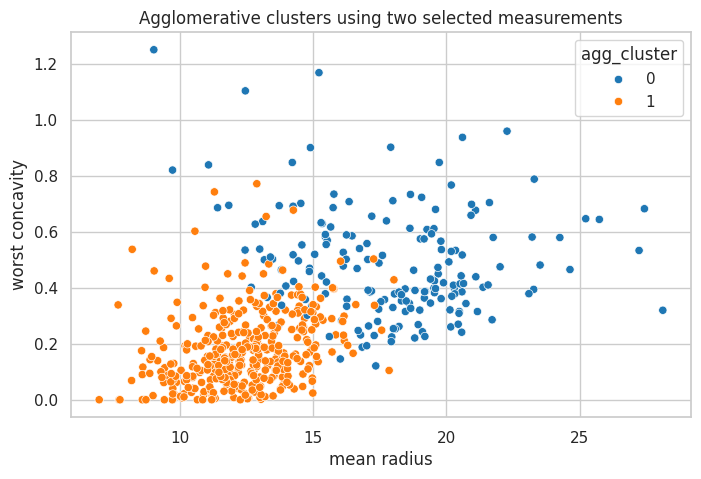

In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cluster_df,
    x="mean radius",
    y="worst concavity",
    hue="agg_cluster",
    palette="tab10",
)
plt.title("Agglomerative clusters using two selected measurements")
plt.show()

**Code explanation**

- K-Means and agglomerative clustering can produce different groupings.
- Both depend on selected features and scaling.
- Agreement between methods can support an interpretation, but it still does not prove that clusters are clinically meaningful.

**Question 24 — Comparing clustering methods**

Why might K-Means and agglomerative clustering create different clusters?

<details>
<summary>Solution</summary>

They use different algorithms.

K-Means represents clusters using centroids. Agglomerative clustering repeatedly merges observations or groups based on linkage rules. Because the definitions differ, the results can differ.

</details>

## 6. Connect the Lab to Real Project Practice

This lab follows a simplified version of real project practice.

In a real project, engineers and analysts usually:

1. clarify the business objective;
2. understand where the data came from;
3. inspect the schema and row meaning;
4. check missing values, duplicates, distributions, and unusual values;
5. decide which columns are features and which column is the target;
6. split data before learned preprocessing;
7. compare against a baseline;
8. evaluate using metrics that match the problem;
9. inspect errors, not only overall scores;
10. explain limitations clearly.

For this lab, we deliberately keep the implementation simple. We do not use pipelines, grid search, cross-validation, custom transformers, or deployment monitoring as required mechanics.

Those are useful real-world ideas, but the goal here is to review the concepts covered in class.

**Question 25 — Real-world limitation**

Why is a high test score not enough to declare this system ready for medical use?

<details>
<summary>Solution</summary>

Medical use requires much more than a classroom test score.

The system would need careful validation, expert review, ethical review, monitoring, documentation, and safety processes. This lab teaches machine-learning workflow; it does not create a deployable medical system.

</details>

## 7. Final Concept Review and Exam-Style Questions

### Q1. What is classification?

<details>
<summary>Answer</summary>

Classification is supervised learning where the target is a category or class.

</details>

### Q2. Why is the cancer dataset a binary classification problem?

<details>
<summary>Answer</summary>

It has two target classes: malignant and benign.

</details>

### Q3. What is the difference between classification and regression?

<details>
<summary>Answer</summary>

Classification predicts a class label.

Regression predicts a numerical value.

</details>

### Q4. What is a baseline classifier?

<details>
<summary>Answer</summary>

A baseline classifier is a simple reference model, such as always predicting the most frequent class.

It helps us decide whether a real model has learned something useful.

</details>

### Q5. What does accuracy measure?

<details>
<summary>Answer</summary>

Accuracy measures the proportion of predictions that are correct.

</details>

### Q6. Why can accuracy be misleading?

<details>
<summary>Answer</summary>

Accuracy can hide poor performance on a specific class, especially when classes are imbalanced or when one type of error is more serious than another.

</details>

### Q7. What does precision measure?

<details>
<summary>Answer</summary>

Precision answers:

```text
Of the observations predicted as a class, how many were actually that class?
```

</details>

### Q8. What does recall measure?

<details>
<summary>Answer</summary>

Recall answers:

```text
Of the observations that actually belong to a class, how many did the model identify?
```

</details>

### Q9. What does F1 measure?

<details>
<summary>Answer</summary>

F1 combines precision and recall into one metric.

It is useful when we want to consider both false positives and false negatives.

</details>

### Q10. What does a confusion matrix show?

<details>
<summary>Answer</summary>

A confusion matrix shows counts of actual classes versus predicted classes.

The diagonal contains correct predictions. Off-diagonal cells contain mistakes.

</details>

### Q11. Why does KNN need scaling?

<details>
<summary>Answer</summary>

KNN uses distances.

If features are on very different numerical scales, large-scale features can dominate the distance calculation.

</details>

### Q12. Why does a decision tree not require scaling in the same way as KNN?

<details>
<summary>Answer</summary>

A decision tree uses feature thresholds to split the data.

It does not calculate nearest-neighbor distances, so feature scale does not affect it in the same way.

</details>

### Q13. What does `fit()` do in classification?

<details>
<summary>Answer</summary>

`fit()` trains the classifier using input features and known target labels.

</details>

### Q14. What does `predict()` do in classification?

<details>
<summary>Answer</summary>

`predict()` uses the trained classifier to assign class labels to new input rows.

</details>

### Q15. What is data leakage?

<details>
<summary>Answer</summary>

Data leakage occurs when information from the test set or target leaks into training or preprocessing.

It can make evaluation look better than it really is.

</details>

### Q16. Why do we split before fitting the scaler?

<details>
<summary>Answer</summary>

The scaler learns means and standard deviations.

If it learns them from the full dataset, then test-set information influences preprocessing. We fit it on training data only and apply the learned transformation to the test data.

</details>

### Q17. What is clustering?

<details>
<summary>Answer</summary>

Clustering is unsupervised learning that groups observations based on feature similarity.

</details>

### Q18. Why should diagnosis not be used as a clustering feature?

<details>
<summary>Answer</summary>

Diagnosis is the known label.

If we include it in clustering, the clusters are partly based on the answer. For unsupervised profile discovery, we use measurement features only.

</details>

### Q19. What does inertia measure in K-Means?

<details>
<summary>Answer</summary>

Inertia measures the total squared distance from observations to their assigned cluster centers.

</details>

### Q20. What does silhouette score measure?

<details>
<summary>Answer</summary>

Silhouette score compares how close observations are to their own cluster versus the nearest other cluster.

Higher values generally indicate better separated clusters under the selected features and distance measure.

</details>

### Q21. Why are cluster labels arbitrary?

<details>
<summary>Answer</summary>

Cluster numbers are names assigned by the algorithm.

Cluster `0` is not automatically better, worse, benign, or malignant. We must inspect the cluster profiles.

</details>

### Q22. What is a false negative for the malignant class?

<details>
<summary>Answer</summary>

It is an actual malignant case that the model predicts as benign.

</details>

### Q23. What is a false positive for the malignant class?

<details>
<summary>Answer</summary>

It is an actual benign case that the model predicts as malignant.

</details>

### Q24. Why compare a model to a baseline?

<details>
<summary>Answer</summary>

A baseline gives context.

If a model barely improves over a simple baseline, it may not be useful even if its score looks reasonable.

</details>

### Q25. What is the main limitation of this lab system?

<details>
<summary>Answer</summary>

It is a classroom learning system.

It demonstrates end-to-end classification and clustering concepts, but it is not validated for real medical decision making.

</details>